# Quicklook: SMOS-IC IVs + TC (ASCAT/SMOS-IC)

This notebook makes fast assessment plots from `.mat` outputs in:

- `/Users/amfox/Desktop/SMOS_IC`

Inputs:

- `Rdiff_DAv8_M36_cd_minus_OLv8_M36_cd_SMOSIC.mat`
- `ASCL4_SMOSIC_OLv8_M36_cd_TC_stats_201808_202405.mat`
- `ASCL4_SMOSIC_DAv8_M36_cd_TC_stats_201808_202405.mat`

Figures:

1. IV `ΔanomR` map (`DA - OL`)
2. TC `R_mod` maps (OL, DA) + `ΔR_mod` map (`DA - OL`)
3. Histograms for IV `ΔanomR` and TC `ΔR_mod`

Map settings:

- Projection: **Robinson**
- Latitude domain: **-40° <= lat <= +40° (CYGNSS)**


In [6]:
from pathlib import Path
import os
import sys
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

# PROJ guard (helps when pyproj/cartopy cannot locate proj.db)
_proj_guess = Path(sys.prefix) / 'share' / 'proj'
if _proj_guess.exists():
    os.environ.setdefault('PROJ_LIB', str(_proj_guess))
    os.environ.setdefault('PROJ_DATA', str(_proj_guess))

# Optional local cartopy cache (helps on systems without internet)
_cartopy_local = Path.home() / '.local' / 'share' / 'cartopy'
if _cartopy_local.exists():
    os.environ.setdefault('CARTOPY_DATA_DIR', str(_cartopy_local))

import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.style.use('default')


In [7]:
MAT_DIR = Path('/Users/amfox/Desktop/SMOS_IC')

RDIFF_FILE = MAT_DIR / 'Rdiff_DAv8_M36_cd_minus_OLv8_M36_cd_SMOSIC.mat'
TC_OL_FILE = MAT_DIR / 'ASCL4_SMOSIC_OLv8_M36_cd_TC_stats_201808_202405.mat'
TC_DA_FILE = MAT_DIR / 'ASCL4_SMOSIC_DAv8_M36_cd_TC_stats_201808_202405.mat'

FIG_DIR = MAT_DIR / 'figures_quicklook'
try:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
except PermissionError:
    FIG_DIR = Path.cwd() / 'figures_smosic_quicklook'
    FIG_DIR.mkdir(parents=True, exist_ok=True)

LAT_MIN = -40.0
LAT_MAX = 40.0
N_LON = 964
N_LAT = 406
NMIN_FLOOR = 50

assert RDIFF_FILE.exists(), RDIFF_FILE
assert TC_OL_FILE.exists(), TC_OL_FILE
assert TC_DA_FILE.exists(), TC_DA_FILE

print(f'MAT_DIR={MAT_DIR}')
print(f'FIG_DIR={FIG_DIR}')


MAT_DIR=/Users/amfox/Desktop/SMOS_IC
FIG_DIR=/Users/amfox/Desktop/SMOS_IC/figures_quicklook


In [8]:
def _vec(x):
    return np.asarray(x, dtype=float).reshape(-1)


def vec_to_grid(v, nlon=N_LON, nlat=N_LAT):
    v = _vec(v)
    if v.size != nlon * nlat:
        raise ValueError(f'Expected {nlon*nlat} cells, got {v.size}')
    # MATLAB flattening from [nlon, nlat] with column-major order
    return v.reshape((nlon, nlat), order='F').T  # -> [nlat, nlon]


def tc_r_from_r2(r2_grid):
    r2 = np.asarray(r2_grid, dtype=float)
    r2 = np.where((r2 >= 0.001) & np.isfinite(r2), np.clip(r2, 0.0, 1.0), np.nan)
    return np.sqrt(r2)


def masked_mean(x):
    x = np.asarray(x, dtype=float)
    return float(np.nanmean(x)) if np.isfinite(x).any() else np.nan


def map_setup(ax, lat_min=LAT_MIN, lat_max=LAT_MAX):
    ax.set_extent([-180, 180, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.25)
    gl = ax.gridlines(crs=ccrs.PlateCarree(), linewidth=0.2, color='0.7', alpha=0.5, linestyle='-')
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = False
    gl.bottom_labels = False


In [9]:
# ---------- Load inputs ----------
M_rdiff = sio.loadmat(RDIFF_FILE, squeeze_me=True, struct_as_record=False)
M_ol = sio.loadmat(TC_OL_FILE, squeeze_me=True, struct_as_record=False)
M_da = sio.loadmat(TC_DA_FILE, squeeze_me=True, struct_as_record=False)

lon_grid = vec_to_grid(M_rdiff['lons'])
lat_grid = vec_to_grid(M_rdiff['lats'])
rdiff_iv = vec_to_grid(M_rdiff['Rdiff_vector'])

# TC model skill (R from R^2)
R_ol = tc_r_from_r2(vec_to_grid(M_ol['R2_TC_mod']))
R_da = tc_r_from_r2(vec_to_grid(M_da['R2_TC_mod']))
dR_tc = R_da - R_ol

# TC sample-count mask
N_ol = vec_to_grid(M_ol['N_sm'])
N_da = vec_to_grid(M_da['N_sm'])
nmin_ol = int(np.asarray(M_ol.get('Nmin', NMIN_FLOOR)).reshape(-1)[0])
nmin_da = int(np.asarray(M_da.get('Nmin', NMIN_FLOOR)).reshape(-1)[0])
NMIN = max(NMIN_FLOOR, nmin_ol, nmin_da)

mask_tc = (N_ol >= NMIN) & (N_da >= NMIN)
for arr in (R_ol, R_da, dR_tc):
    arr[~mask_tc] = np.nan

# Latitude domain mask for all maps (CYGNSS: |lat| <= 40)
domain_mask = (lat_grid < LAT_MIN) | (lat_grid > LAT_MAX)
for arr in (rdiff_iv, R_ol, R_da, dR_tc):
    arr[domain_mask] = np.nan

print('Grid shape:', lat_grid.shape)
print('Using NMIN:', NMIN)
print('Finite cells | IV dR:', int(np.isfinite(rdiff_iv).sum()))
print('Finite cells | TC R_ol:', int(np.isfinite(R_ol).sum()))
print('Finite cells | TC R_da:', int(np.isfinite(R_da).sum()))
print('Finite cells | TC dR:', int(np.isfinite(dR_tc).sum()))

# ---------- Coverage diagnostics ----------
mask_lat = (lat_grid >= LAT_MIN) & (lat_grid <= LAT_MAX)
lat_cells = int(mask_lat.sum())
mask_n1 = (N_ol >= 1) & mask_lat
mask_n50 = (N_ol >= NMIN) & mask_lat

print('\nCoverage audit (TC within ±40°):')
print(f'  Cells in lat band: {lat_cells:,}')
print(f'  Cells with N_sm >= 1: {int(mask_n1.sum()):,} ({100.0*mask_n1.sum()/lat_cells:.2f}%)')
print(f'  Cells with N_sm >= {NMIN}: {int(mask_n50.sum()):,} ({100.0*mask_n50.sum()/lat_cells:.2f}%)')
print(f'  Finite R2_TC_mod | OL, N>=1: {int((np.isfinite(vec_to_grid(M_ol["R2_TC_mod"])) & mask_n1).sum()):,}')
print(f'  Finite R2_TC_mod | DA, N>=1: {int((np.isfinite(vec_to_grid(M_da["R2_TC_mod"])) & mask_n1).sum()):,}')
print(f'  Finite R_mod after notebook mask | OL: {int((np.isfinite(R_ol) & mask_lat).sum()):,} ({100.0*(np.isfinite(R_ol) & mask_lat).sum()/lat_cells:.2f}%)')
print(f'  Finite R_mod after notebook mask | DA: {int((np.isfinite(R_da) & mask_lat).sum()):,} ({100.0*(np.isfinite(R_da) & mask_lat).sum()/lat_cells:.2f}%)')
print(f'  Finite ΔR_mod after notebook mask: {int((np.isfinite(dR_tc) & mask_lat).sum()):,} ({100.0*(np.isfinite(dR_tc) & mask_lat).sum()/lat_cells:.2f}%)')

print('\nNMIN sensitivity (TC finite cells in ±40°):')
for n_test in (1, 20, 50, 100):
    m_ol = (N_ol >= n_test) & mask_lat
    m_da = (N_da >= n_test) & mask_lat
    m_joint = m_ol & m_da
    c_ol = int((np.isfinite(R_ol) & m_ol).sum())
    c_da = int((np.isfinite(R_da) & m_da).sum())
    c_dr = int((np.isfinite(dR_tc) & m_joint).sum())
    print(f'  N>={n_test:>3}: OL={c_ol:,}, DA={c_da:,}, dR={c_dr:,}')


Grid shape: (406, 964)
Using NMIN: 50
Finite cells | IV dR: 5103
Finite cells | TC R_ol: 9288
Finite cells | TC R_da: 9467
Finite cells | TC dR: 8844

Coverage audit (TC within ±40°):
  Cells in lat band: 252,568
  Cells with N_sm >= 1: 14,337 (5.68%)
  Cells with N_sm >= 50: 14,246 (5.64%)
  Finite R2_TC_mod | OL, N>=1: 9,334
  Finite R2_TC_mod | DA, N>=1: 9,508
  Finite R_mod after notebook mask | OL: 9,288 (3.68%)
  Finite R_mod after notebook mask | DA: 9,467 (3.75%)
  Finite ΔR_mod after notebook mask: 8,844 (3.50%)

NMIN sensitivity (TC finite cells in ±40°):
  N>=  1: OL=9,288, DA=9,467, dR=8,844
  N>= 20: OL=9,288, DA=9,467, dR=8,844
  N>= 50: OL=9,288, DA=9,467, dR=8,844
  N>=100: OL=9,221, DA=9,398, dR=8,779


/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: inv

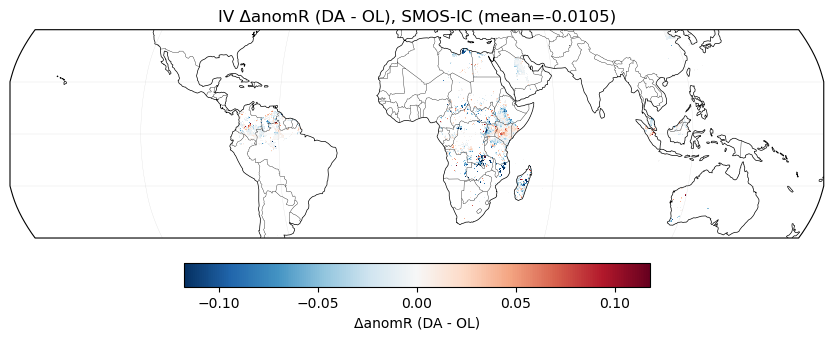

Wrote: /Users/amfox/Desktop/SMOS_IC/figures_quicklook/quicklook_smosic_iv_danomr_da_minus_ol.png


In [10]:
# ---------- Figure 1: IV ΔanomR (DA - OL) ----------
proj = ccrs.Robinson(central_longitude=0)

lim_iv = np.nanquantile(np.abs(rdiff_iv), 0.98)
lim_iv = float(np.clip(lim_iv, 0.02, 0.5))

fig = plt.figure(figsize=(10.5, 5.5))
ax = fig.add_subplot(1, 1, 1, projection=proj)

pcm = ax.pcolormesh(
    lon_grid,
    lat_grid,
    rdiff_iv,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',   # positive (improvement) is blue
    vmin=-lim_iv,
    vmax=lim_iv,
    shading='auto',
)

map_setup(ax)
mu = masked_mean(rdiff_iv)
ax.set_title(f'IV ΔanomR (DA - OL), SMOS-IC (mean={mu:+.4f})')

cb = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.06, fraction=0.055)
cb.set_label('ΔanomR (DA - OL)')

fig_path = FIG_DIR / 'quicklook_smosic_iv_danomr_da_minus_ol.png'
fig.savefig(fig_path, dpi=220, bbox_inches='tight')
plt.show()
print(f'Wrote: {fig_path}')


/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: inv

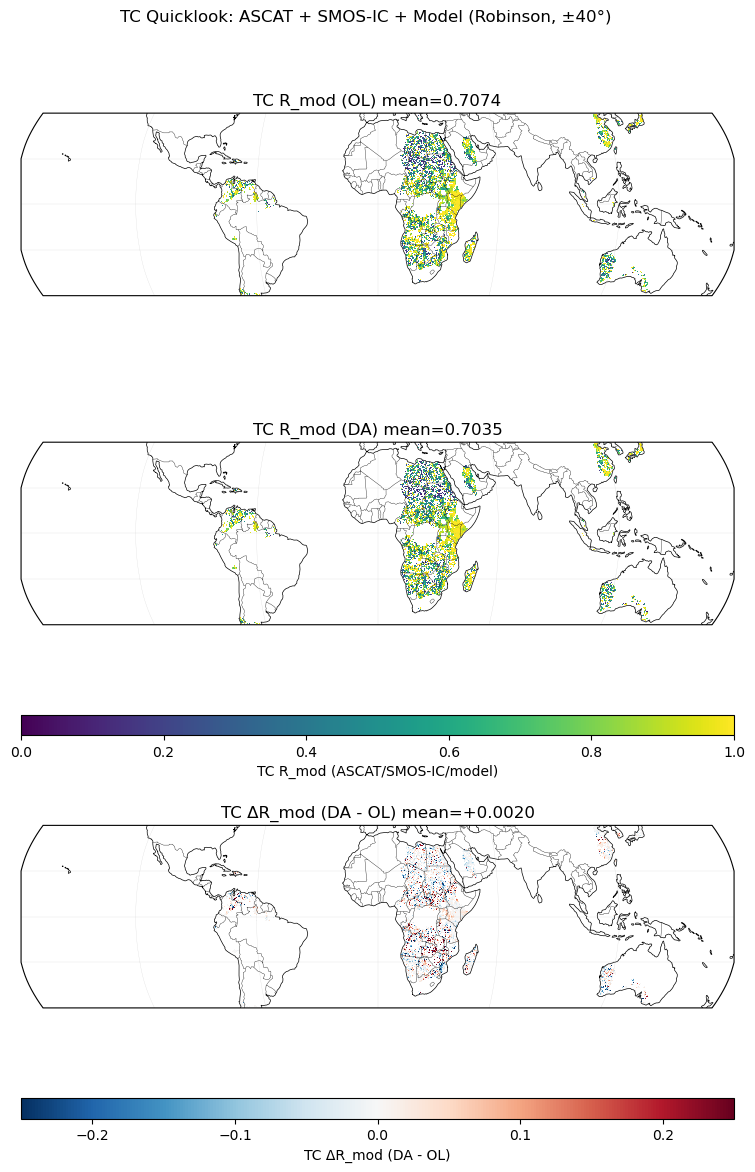

Wrote: /Users/amfox/Desktop/SMOS_IC/figures_quicklook/quicklook_smosic_tc_rmod_ol_da_delta.png


In [11]:
# ---------- Figure 2: TC R_mod (OL, DA) + ΔR_mod ----------
proj = ccrs.Robinson(central_longitude=0)

lim_dR = np.nanquantile(np.abs(dR_tc), 0.98)
lim_dR = float(np.clip(lim_dR, 0.01, 0.25))

fig = plt.figure(figsize=(9.2, 11.8))
gs = fig.add_gridspec(
    nrows=5, ncols=1,
    height_ratios=[1.0, 1.0, 0.07, 1.0, 0.07],
    hspace=0.18,
)
axes = [
    fig.add_subplot(gs[0, 0], projection=proj),
    fig.add_subplot(gs[1, 0], projection=proj),
    fig.add_subplot(gs[3, 0], projection=proj),
]
cax1 = fig.add_subplot(gs[2, 0])
cax2 = fig.add_subplot(gs[4, 0])

# OL
m0 = axes[0].pcolormesh(
    lon_grid, lat_grid, R_ol,
    transform=ccrs.PlateCarree(), cmap='viridis', vmin=0.0, vmax=1.0, shading='auto'
)
map_setup(axes[0])
axes[0].set_title(f'TC R_mod (OL) mean={masked_mean(R_ol):.4f}')

# DA
m1 = axes[1].pcolormesh(
    lon_grid, lat_grid, R_da,
    transform=ccrs.PlateCarree(), cmap='viridis', vmin=0.0, vmax=1.0, shading='auto'
)
map_setup(axes[1])
axes[1].set_title(f'TC R_mod (DA) mean={masked_mean(R_da):.4f}')

# Delta
m2 = axes[2].pcolormesh(
    lon_grid, lat_grid, dR_tc,
    transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin=-lim_dR, vmax=lim_dR, shading='auto'
)
map_setup(axes[2])
axes[2].set_title(f'TC ΔR_mod (DA - OL) mean={masked_mean(dR_tc):+.4f}')

# Colorbars
cb1 = fig.colorbar(m0, cax=cax1, orientation='horizontal')
cb1.set_label('TC R_mod (ASCAT/SMOS-IC/model)')

cb2 = fig.colorbar(m2, cax=cax2, orientation='horizontal')
cb2.set_label('TC ΔR_mod (DA - OL)')

fig.suptitle('TC Quicklook: ASCAT + SMOS-IC + Model (Robinson, ±40°)', y=0.995)
fig.subplots_adjust(top=0.955, bottom=0.055)

fig_path = FIG_DIR / 'quicklook_smosic_tc_rmod_ol_da_delta.png'
fig.savefig(fig_path, dpi=220, bbox_inches='tight')
plt.show()
print(f'Wrote: {fig_path}')


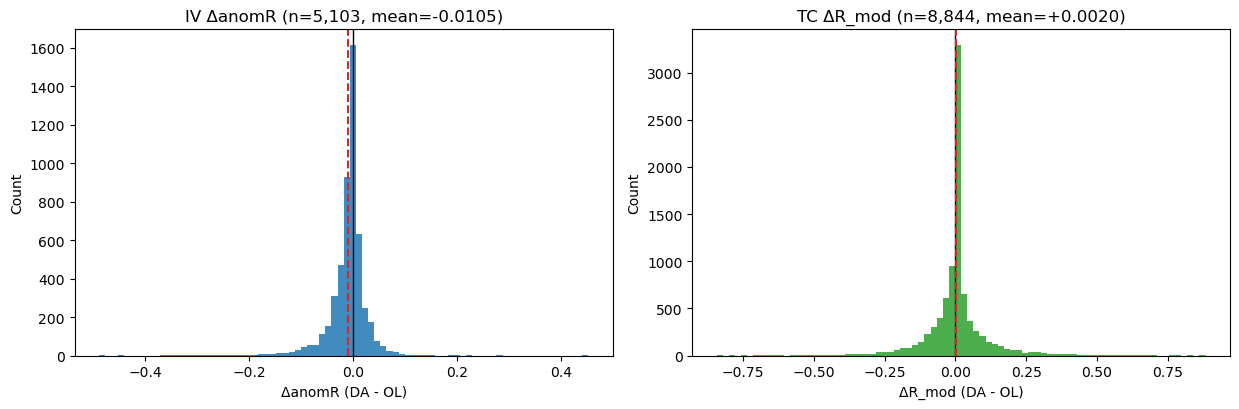

Wrote: /Users/amfox/Desktop/SMOS_IC/figures_quicklook/quicklook_smosic_iv_tc_histograms.png


In [12]:
# ---------- Figure 3: Histograms ----------
iv_vals = rdiff_iv[np.isfinite(rdiff_iv)]
tc_vals = dR_tc[np.isfinite(dR_tc)]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

axes[0].hist(iv_vals, bins=80, color='tab:blue', alpha=0.85)
axes[0].axvline(0, color='k', lw=1)
axes[0].axvline(np.nanmean(iv_vals), color='tab:red', lw=1.5, ls='--')
axes[0].set_title(f'IV ΔanomR (n={iv_vals.size:,}, mean={np.nanmean(iv_vals):+.4f})')
axes[0].set_xlabel('ΔanomR (DA - OL)')
axes[0].set_ylabel('Count')

axes[1].hist(tc_vals, bins=80, color='tab:green', alpha=0.85)
axes[1].axvline(0, color='k', lw=1)
axes[1].axvline(np.nanmean(tc_vals), color='tab:red', lw=1.5, ls='--')
axes[1].set_title(f'TC ΔR_mod (n={tc_vals.size:,}, mean={np.nanmean(tc_vals):+.4f})')
axes[1].set_xlabel('ΔR_mod (DA - OL)')
axes[1].set_ylabel('Count')

fig.tight_layout()
fig_path = FIG_DIR / 'quicklook_smosic_iv_tc_histograms.png'
fig.savefig(fig_path, dpi=220, bbox_inches='tight')
plt.show()
print(f'Wrote: {fig_path}')


/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_84511/342272434.py:40: RuntimeWarning: divide by zero encountered in divide
  ret_frac = np.where(nobs_pre_plot > 0, nsm_tc_plot / nobs_pre_plot, np.nan)
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_84511/342272434.py:40: RuntimeWarning: invalid value encountered in divide
  ret_frac = np.where(nobs_pre_plot > 0, nsm_tc_plot / nobs_pre_plot, np.nan)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered 

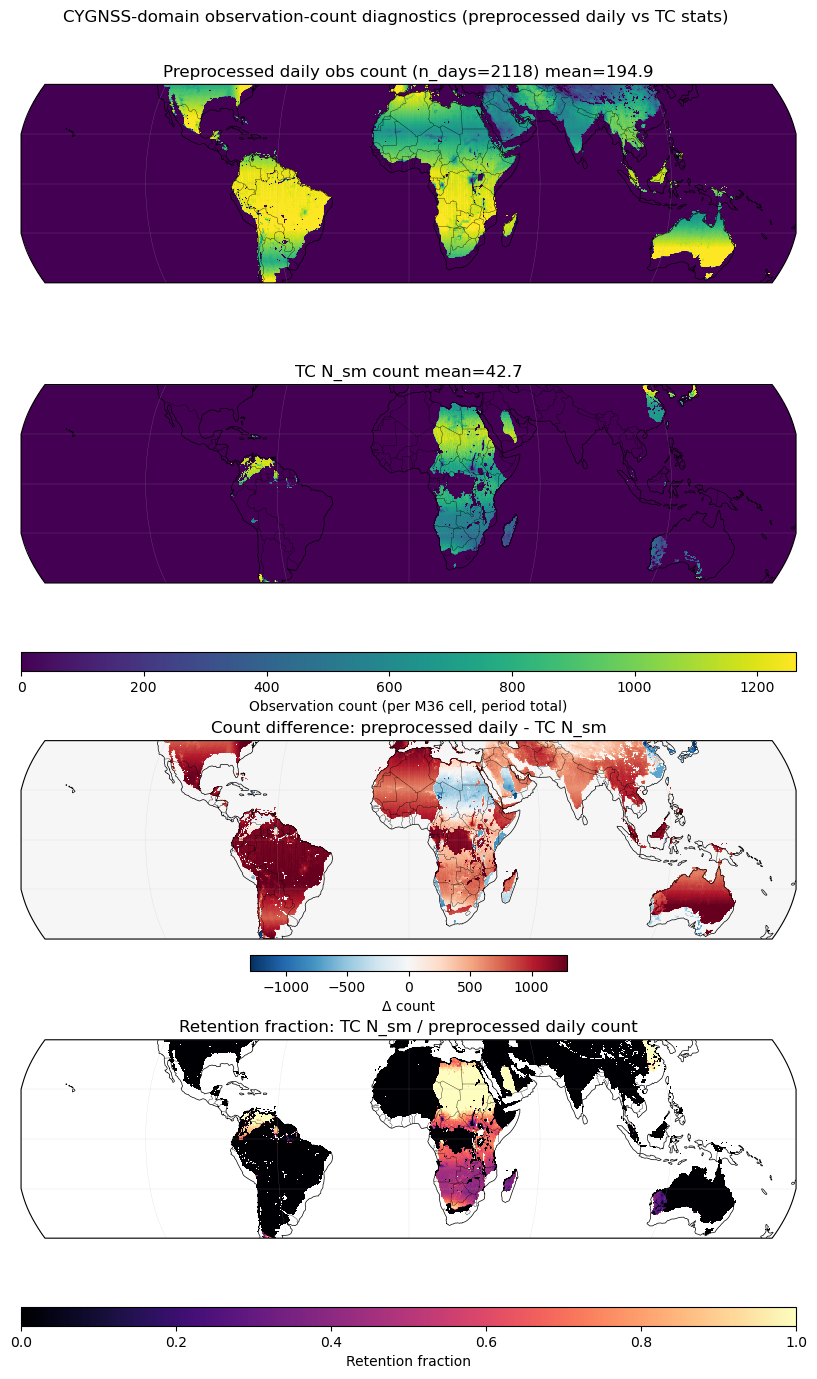

Wrote: /Users/amfox/Desktop/SMOS_IC/figures_quicklook/quicklook_smosic_obscount_preproc_vs_tc_nsm.png

Coverage summary (±40°):
  cells in band: 252,568
  cells with preprocessed obs > 0: 52,031
  cells with TC N_sm > 0: 14,337
  total preprocessed obs (sum over cells): 49,219,904
  total TC N_sm (sum over cells): 10,795,689
  overall retention (sum N_sm / sum preprocessed): 0.219


In [13]:
# ---------- Figure 4: Observation counts from preprocessed daily files vs TC N_sm ----------
from datetime import datetime
from netCDF4 import Dataset

PREPROC_DIR = Path('/Users/amfox/Desktop/geosldas-analysis/projects/SMOS_IC/output/preprocessed_m36_daily')
assert PREPROC_DIR.exists(), PREPROC_DIR

# Match TC stats period from filenames: 201808..202405 (inclusive)
tc_start = datetime.strptime('20180801', '%Y%m%d').date()
tc_end = datetime.strptime('20240531', '%Y%m%d').date()

daily_files = sorted(PREPROC_DIR.glob('smos_ic_sm_m36_*.nc'))
assert daily_files, f'No daily preprocessed files found in {PREPROC_DIR}'

nobs_lin = np.zeros(N_LAT * N_LON, dtype=np.int64)
n_days_used = 0
for f in daily_files:
    tag = f.stem.split('_')[-1]
    try:
        d = datetime.strptime(tag, '%Y%m%d').date()
    except ValueError:
        continue
    if not (tc_start <= d <= tc_end):
        continue
    with Dataset(f, 'r') as ds:
        idx = np.asarray(ds.variables['idx_EASEv2_lonxlat'][:], dtype=np.int64).reshape(-1)
    # Each retained index in a daily file counts as one preprocessed observation for that day.
    np.add.at(nobs_lin, idx, 1)
    n_days_used += 1

nobs_pre = nobs_lin.reshape((N_LAT, N_LON))
nsm_tc = np.asarray(N_ol, dtype=float)  # N_ol and N_da are effectively identical for this dataset

# CYGNSS-domain mask for plotting
mask_lat = (lat_grid >= LAT_MIN) & (lat_grid <= LAT_MAX)
nobs_pre_plot = np.where(mask_lat, nobs_pre, np.nan)
nsm_tc_plot = np.where(mask_lat, nsm_tc, np.nan)

dN = nobs_pre_plot - nsm_tc_plot
ret_frac = np.where(nobs_pre_plot > 0, nsm_tc_plot / nobs_pre_plot, np.nan)

vmax_n = float(np.nanquantile(np.r_[nobs_pre_plot[np.isfinite(nobs_pre_plot)], nsm_tc_plot[np.isfinite(nsm_tc_plot)]], 0.99))
vmax_n = max(vmax_n, 1.0)
lim_dN = float(np.nanquantile(np.abs(dN[np.isfinite(dN)]), 0.99))
lim_dN = max(lim_dN, 1.0)

proj = ccrs.Robinson(central_longitude=0)
fig = plt.figure(figsize=(10.0, 14.0))
gs = fig.add_gridspec(nrows=6, ncols=1, height_ratios=[1.0, 1.0, 0.07, 1.0, 1.0, 0.07], hspace=0.20)
axes = [
    fig.add_subplot(gs[0, 0], projection=proj),
    fig.add_subplot(gs[1, 0], projection=proj),
    fig.add_subplot(gs[3, 0], projection=proj),
    fig.add_subplot(gs[4, 0], projection=proj),
]
cax_counts = fig.add_subplot(gs[2, 0])
cax_extra = fig.add_subplot(gs[5, 0])

# Preprocessed daily count
m0 = axes[0].pcolormesh(
    lon_grid, lat_grid, nobs_pre_plot,
    transform=ccrs.PlateCarree(), cmap='viridis', vmin=0.0, vmax=vmax_n, shading='auto'
)
map_setup(axes[0])
axes[0].set_title(f'Preprocessed daily obs count (n_days={n_days_used}) mean={np.nanmean(nobs_pre_plot):.1f}')

# TC N_sm
m1 = axes[1].pcolormesh(
    lon_grid, lat_grid, nsm_tc_plot,
    transform=ccrs.PlateCarree(), cmap='viridis', vmin=0.0, vmax=vmax_n, shading='auto'
)
map_setup(axes[1])
axes[1].set_title(f'TC N_sm count mean={np.nanmean(nsm_tc_plot):.1f}')

cb_counts = fig.colorbar(m0, cax=cax_counts, orientation='horizontal')
cb_counts.set_label('Observation count (per M36 cell, period total)')

# Difference
m2 = axes[2].pcolormesh(
    lon_grid, lat_grid, dN,
    transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin=-lim_dN, vmax=lim_dN, shading='auto'
)
map_setup(axes[2])
axes[2].set_title('Count difference: preprocessed daily - TC N_sm')

# Retention fraction
m3 = axes[3].pcolormesh(
    lon_grid, lat_grid, ret_frac,
    transform=ccrs.PlateCarree(), cmap='magma', vmin=0.0, vmax=1.0, shading='auto'
)
map_setup(axes[3])
axes[3].set_title('Retention fraction: TC N_sm / preprocessed daily count')

cb_extra = fig.colorbar(m2, ax=axes[2], orientation='horizontal', pad=0.06, fraction=0.06)
cb_extra.set_label('Δ count')

cb_ret = fig.colorbar(m3, cax=cax_extra, orientation='horizontal')
cb_ret.set_label('Retention fraction')

fig.suptitle('CYGNSS-domain observation-count diagnostics (preprocessed daily vs TC stats)', y=0.995)
fig.subplots_adjust(top=0.965, bottom=0.055)

fig_path = FIG_DIR / 'quicklook_smosic_obscount_preproc_vs_tc_nsm.png'
fig.savefig(fig_path, dpi=220, bbox_inches='tight')
plt.show()
print(f'Wrote: {fig_path}')

# Scalar summary for quick sanity checks
lat_cells = int(mask_lat.sum())
print('\nCoverage summary (±40°):')
print(f'  cells in band: {lat_cells:,}')
print(f'  cells with preprocessed obs > 0: {int(np.sum((nobs_pre > 0) & mask_lat)):,}')
print(f'  cells with TC N_sm > 0: {int(np.sum((nsm_tc > 0) & mask_lat)):,}')
print(f'  total preprocessed obs (sum over cells): {int(np.nansum(nobs_pre_plot)):,}')
print(f'  total TC N_sm (sum over cells): {int(np.nansum(nsm_tc_plot)):,}')
print(f'  overall retention (sum N_sm / sum preprocessed): {np.nansum(nsm_tc_plot) / np.nansum(nobs_pre_plot):.3f}')


Manifest loss audit (TC period):
  Period: 2018-08-01 .. 2024-05-31
  Days in manifest in period: 2,118
  Days with combined-native count: 2,118
  Days with valid M36 count: 2,118

Stage totals (sum over days):
  ASC native valid total: 81,162,763
  DES native valid total: 81,592,306
  ASC+DES native total: 162,755,069
  Combined native total: 134,977,239
  Valid M36 total: 69,564,077

Retention ratios (period totals):
  Combined native / (ASC+DES): 0.829
  Valid M36 / Combined native: 0.515
  Valid M36 / (ASC+DES): 0.427

Daily Valid M36 / Combined native stats:
  mean=0.519  median=0.526  p05=0.482  p95=0.548

Daily mean_coverage_m36 stats (manifest):
  mean=0.802  median=0.801  p05=0.783  p95=0.826


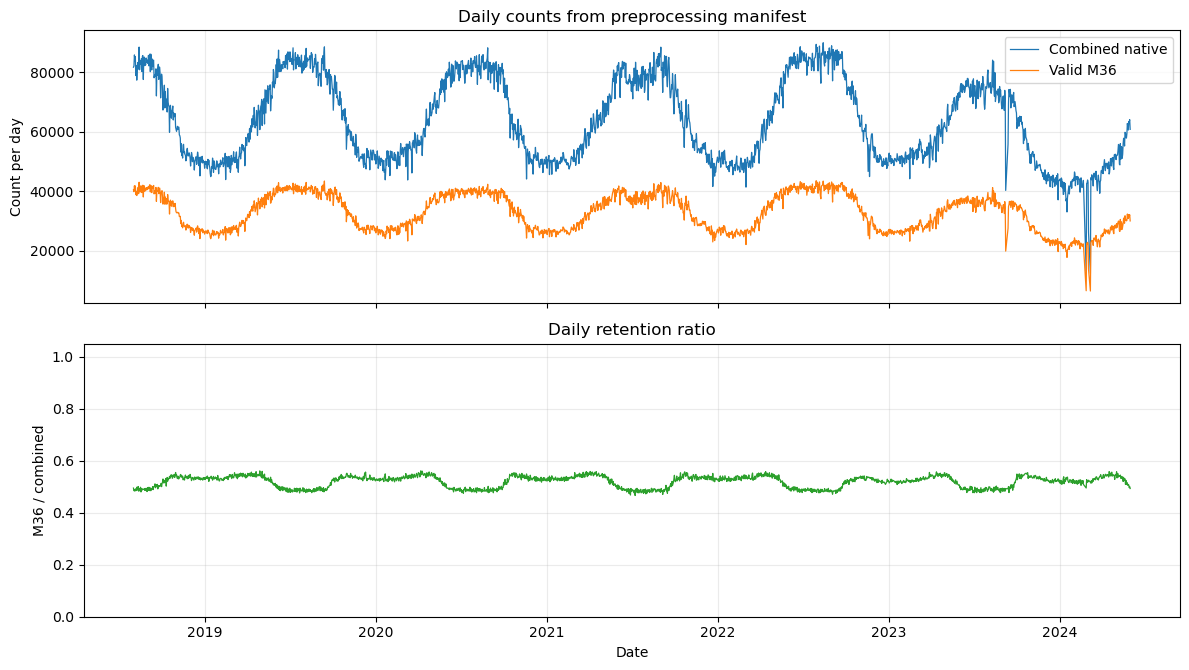

Wrote: /Users/amfox/Desktop/SMOS_IC/figures_quicklook/quicklook_smosic_manifest_loss_audit.png


In [14]:
# ---------- Manifest loss audit: native QC -> merged native -> valid M36 ----------
import csv
from datetime import datetime

manifest_path = PREPROC_DIR / 'smos_ic_m36_daily_manifest.csv'
assert manifest_path.exists(), manifest_path

def _to_num(x):
    x = (x or '').strip()
    return np.nan if x == '' else float(x)

rows = []
with open(manifest_path, 'r', newline='') as f:
    reader = csv.DictReader(f)
    for r in reader:
        d = datetime.strptime(r['date'], '%Y%m%d').date()
        if not (tc_start <= d <= tc_end):
            continue
        rows.append({
            'date': d,
            'n_valid_asc_native': _to_num(r.get('n_valid_asc_native', '')),
            'n_valid_des_native': _to_num(r.get('n_valid_des_native', '')),
            'n_valid_combined_native': _to_num(r.get('n_valid_combined_native', '')),
            'n_valid_m36': _to_num(r.get('n_valid_m36', '')),
            'mean_coverage_m36': _to_num(r.get('mean_coverage_m36', '')),
        })

assert rows, 'No manifest rows found in TC period'

dates = np.array([r['date'] for r in rows])
asc = np.array([r['n_valid_asc_native'] for r in rows], dtype=float)
des = np.array([r['n_valid_des_native'] for r in rows], dtype=float)
comb = np.array([r['n_valid_combined_native'] for r in rows], dtype=float)
m36 = np.array([r['n_valid_m36'] for r in rows], dtype=float)
cov = np.array([r['mean_coverage_m36'] for r in rows], dtype=float)

native_sum = asc + des
valid_comb = np.isfinite(comb)
valid_m36 = np.isfinite(m36)
valid_both = valid_comb & valid_m36 & (comb > 0)

tot_asc = np.nansum(asc)
tot_des = np.nansum(des)
tot_native_sum = np.nansum(native_sum)
tot_comb = np.nansum(comb)
tot_m36 = np.nansum(m36)

ratio_comb_vs_sum = tot_comb / tot_native_sum if tot_native_sum > 0 else np.nan
ratio_m36_vs_comb = tot_m36 / tot_comb if tot_comb > 0 else np.nan
ratio_m36_vs_sum = tot_m36 / tot_native_sum if tot_native_sum > 0 else np.nan

daily_ret = np.where(valid_both, m36 / comb, np.nan)

print('Manifest loss audit (TC period):')
print(f'  Period: {tc_start} .. {tc_end}')
print(f'  Days in manifest in period: {len(rows):,}')
print(f'  Days with combined-native count: {int(np.sum(valid_comb)):,}')
print(f'  Days with valid M36 count: {int(np.sum(valid_m36)):,}')
print('')
print('Stage totals (sum over days):')
print(f'  ASC native valid total: {int(tot_asc):,}')
print(f'  DES native valid total: {int(tot_des):,}')
print(f'  ASC+DES native total: {int(tot_native_sum):,}')
print(f'  Combined native total: {int(tot_comb):,}')
print(f'  Valid M36 total: {int(tot_m36):,}')
print('')
print('Retention ratios (period totals):')
print(f'  Combined native / (ASC+DES): {ratio_comb_vs_sum:.3f}')
print(f'  Valid M36 / Combined native: {ratio_m36_vs_comb:.3f}')
print(f'  Valid M36 / (ASC+DES): {ratio_m36_vs_sum:.3f}')

if np.isfinite(daily_ret).any():
    print('')
    print('Daily Valid M36 / Combined native stats:')
    print(f'  mean={np.nanmean(daily_ret):.3f}  median={np.nanmedian(daily_ret):.3f}  p05={np.nanpercentile(daily_ret,5):.3f}  p95={np.nanpercentile(daily_ret,95):.3f}')

if np.isfinite(cov).any():
    print('')
    print('Daily mean_coverage_m36 stats (manifest):')
    print(f'  mean={np.nanmean(cov):.3f}  median={np.nanmedian(cov):.3f}  p05={np.nanpercentile(cov,5):.3f}  p95={np.nanpercentile(cov,95):.3f}')

# Quick visual diagnostics
fig, axes = plt.subplots(2, 1, figsize=(12.0, 6.8), sharex=True)
axes[0].plot(dates, comb, lw=0.9, color='tab:blue', label='Combined native')
axes[0].plot(dates, m36, lw=0.9, color='tab:orange', label='Valid M36')
axes[0].set_ylabel('Count per day')
axes[0].set_title('Daily counts from preprocessing manifest')
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.25)

axes[1].plot(dates, daily_ret, lw=0.9, color='tab:green')
axes[1].set_ylabel('M36 / combined')
axes[1].set_xlabel('Date')
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.25)
axes[1].set_title('Daily retention ratio')

fig.tight_layout()
fig_path = FIG_DIR / 'quicklook_smosic_manifest_loss_audit.png'
fig.savefig(fig_path, dpi=220, bbox_inches='tight')
plt.show()
print(f'Wrote: {fig_path}')


Native-QC map settings:
  scene_flag_max=1, tb_rmse_max=8.0, sm_range=[0.0, 1.0]
Loaded cached count maps: /Users/amfox/Desktop/geosldas-analysis/projects/SMOS_IC/output/preprocessed_m36_daily/native_qc_vs_m36_count_20180801_20240531_v2.npz


/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: inv

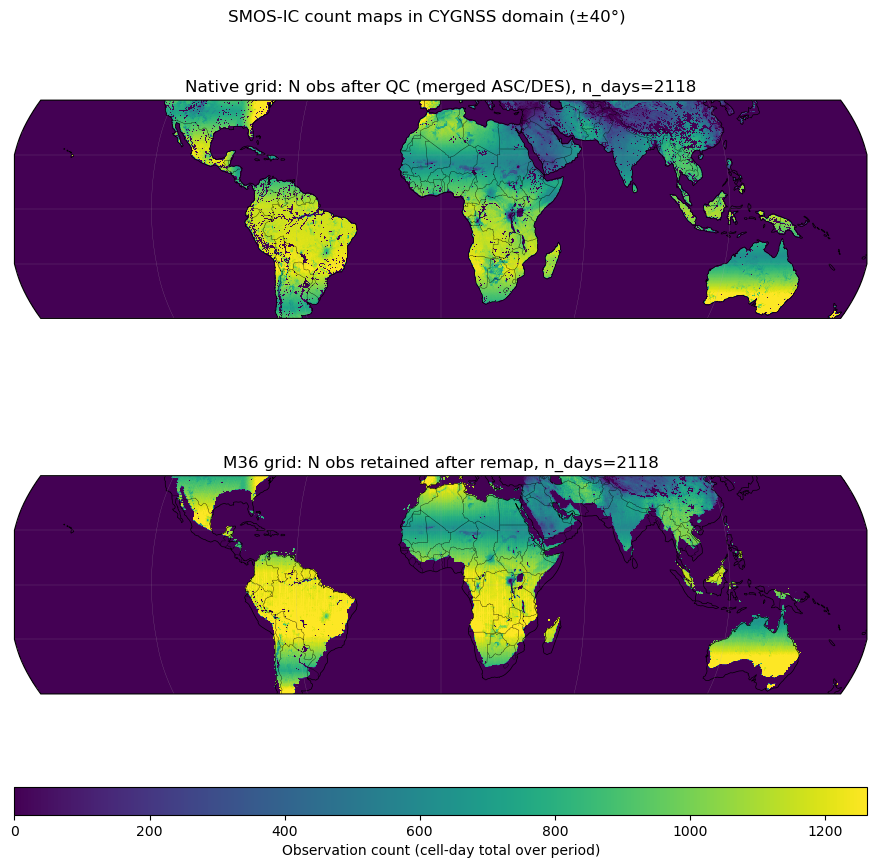

Wrote: /Users/amfox/Desktop/SMOS_IC/figures_quicklook/quicklook_smosic_native_qc_vs_m36_count_maps.png

Count totals in ±40°:
  Native-QC total: 98,419,330
  M36 retained total: 49,219,904
  Retention (M36/native): 0.500


In [15]:
# ---------- Figure 6: Native-QC observation count map vs M36 count map ----------
import re
from datetime import datetime
from netCDF4 import Dataset
from pyproj import Transformer

if 'tc_start' not in globals():
    tc_start = datetime.strptime('20180801', '%Y%m%d').date()
if 'tc_end' not in globals():
    tc_end = datetime.strptime('20240531', '%Y%m%d').date()

SMOS_ROOT = Path('/Users/amfox/Desktop/SMOS_IC')
PREPROC_DIR = Path('/Users/amfox/Desktop/geosldas-analysis/projects/SMOS_IC/output/preprocessed_m36_daily')

assert SMOS_ROOT.exists(), SMOS_ROOT
assert PREPROC_DIR.exists(), PREPROC_DIR

asc_dirs = [SMOS_ROOT / 'SMOS_IC_V2_ASC_2018_2021', SMOS_ROOT / 'SMOS_IC_V2_ASC']
des_dirs = [SMOS_ROOT / 'SMOS_IC_V2_DES_2018_2021', SMOS_ROOT / 'SMOS_IC_OPER_DES']

DATE_RE = re.compile(r'_(20\d{6})T')


def _parse_date_from_name(name):
    m = DATE_RE.search(name)
    if not m:
        return None
    return datetime.strptime(m.group(1), '%Y%m%d').date()


def _build_file_index(dirs):
    out = {}
    for d in dirs:
        if not d.exists():
            continue
        for f in sorted(d.glob('*.nc')):
            dt = _parse_date_from_name(f.name)
            if dt is not None:
                out[dt] = f
    return out


def _filled(arr):
    if np.ma.isMaskedArray(arr):
        return arr.filled(np.nan)
    return np.asarray(arr)


def _read_qc_mask(path, scene_flag_max, tb_rmse_max, sm_min, sm_max):
    with Dataset(path, 'r') as ds:
        sm = _filled(ds.variables['Soil_Moisture'][:]).astype(np.float64)
        sf = _filled(ds.variables['Scene_Flags'][:]).astype(np.float64)
        rm = _filled(ds.variables['RMSE'][:]).astype(np.float64)

    good = (
        np.isfinite(sm)
        & np.isfinite(sf)
        & np.isfinite(rm)
        & (sf <= float(scene_flag_max))
        & (rm <= float(tb_rmse_max))
        & (sm >= float(sm_min))
        & (sm <= float(sm_max))
    )
    return good


def _native_lonlat_from_file(path):
    with Dataset(path, 'r') as ds:
        sm = ds.variables['Soil_Moisture']
        shape = tuple(int(n) for n in sm.shape)

        # Prefer file lon/lat coordinates (index-aligned with Soil_Moisture).
        if 'lon' in ds.variables and 'lat' in ds.variables:
            lon_v = _filled(ds.variables['lon'][:]).astype(np.float64)
            lat_v = _filled(ds.variables['lat'][:]).astype(np.float64)

            if lon_v.ndim == 2 and lat_v.ndim == 2 and lon_v.shape == shape and lat_v.shape == shape:
                lon = lon_v
                lat = lat_v
                lon = ((lon + 180.0) % 360.0) - 180.0
                return lon.astype(np.float32), lat.astype(np.float32)

            if lon_v.ndim == 1 and lat_v.ndim == 1:
                n0, n1 = shape
                if lat_v.size == n0 and lon_v.size == n1:
                    lon, lat = np.meshgrid(lon_v, lat_v)
                    lon = ((lon + 180.0) % 360.0) - 180.0
                    return lon.astype(np.float32), lat.astype(np.float32)
                if lon_v.size == n0 and lat_v.size == n1:
                    lon, lat = np.meshgrid(lon_v, lat_v, indexing='ij')
                    lon = ((lon + 180.0) % 360.0) - 180.0
                    return lon.astype(np.float32), lat.astype(np.float32)

        # Fallback: derive lon/lat from projection geotransform.
        crs_var = ds.variables['crs']
        if not hasattr(crs_var, 'GeoTransform'):
            raise KeyError(f'{path} missing lon/lat-compatible coordinates and crs.GeoTransform')
        gt = [float(v) for v in str(crs_var.GeoTransform).split()]
        src_crs = getattr(crs_var, 'spatial_ref', None) or getattr(crs_var, 'crs_wkt', None) or 'EPSG:6933'

    nlat, nlon = shape
    x0, dx, _, y0, _, dy = gt

    # GeoTransform origin is pixel corner; shift by +0.5 cell to centers.
    x_ctr = x0 + (np.arange(nlon, dtype=np.float64) + 0.5) * dx
    y_ctr = y0 + (np.arange(nlat, dtype=np.float64) + 0.5) * dy
    xx, yy = np.meshgrid(x_ctr, y_ctr)

    tx = Transformer.from_crs(src_crs, 'EPSG:4326', always_xy=True)
    lon, lat = tx.transform(xx, yy)
    lon = ((lon + 180.0) % 360.0) - 180.0
    return lon.astype(np.float32), lat.astype(np.float32)


# Read QC thresholds from one preprocessed file so this cell mirrors preprocessing settings.
preproc_files = sorted(PREPROC_DIR.glob('smos_ic_sm_m36_*.nc'))
assert preproc_files, f'No preprocessed daily files found in {PREPROC_DIR}'

scene_flag_max = 1
tb_rmse_max = 8.0
sm_min = 0.0
sm_max = 1.0
for f in preproc_files:
    tag = f.stem.split('_')[-1]
    try:
        d = datetime.strptime(tag, '%Y%m%d').date()
    except ValueError:
        continue
    if tc_start <= d <= tc_end:
        with Dataset(f, 'r') as ds:
            scene_flag_max = int(getattr(ds, 'qc_scene_flag_max', scene_flag_max))
            tb_rmse_max = float(getattr(ds, 'qc_tb_rmse_max', tb_rmse_max))
            sm_min = float(getattr(ds, 'qc_sm_min', sm_min))
            sm_max = float(getattr(ds, 'qc_sm_max', sm_max))
        break

print('Native-QC map settings:')
print(f'  scene_flag_max={scene_flag_max}, tb_rmse_max={tb_rmse_max}, sm_range=[{sm_min}, {sm_max}]')

CACHE_VERSION = 'v2'
CACHE_NPZ = PREPROC_DIR / f'native_qc_vs_m36_count_{tc_start:%Y%m%d}_{tc_end:%Y%m%d}_{CACHE_VERSION}.npz'

if CACHE_NPZ.exists():
    Z = np.load(CACHE_NPZ)
    nobs_native_qc = Z['nobs_native_qc']
    lon_native = Z['lon_native']
    lat_native = Z['lat_native']
    nobs_m36 = Z['nobs_m36']
    n_days_native = int(Z['n_days_native'])
    n_days_m36 = int(Z['n_days_m36'])
    print(f'Loaded cached count maps: {CACHE_NPZ}')
else:
    asc_idx = _build_file_index(asc_dirs)
    des_idx = _build_file_index(des_dirs)
    run_dates = sorted(d for d in (set(asc_idx.keys()) | set(des_idx.keys())) if (tc_start <= d <= tc_end))

    assert run_dates, 'No ASC/DES dates in requested period'

    sample_native = asc_idx.get(run_dates[0], None) or des_idx.get(run_dates[0], None)
    assert sample_native is not None

    lon_native, lat_native = _native_lonlat_from_file(sample_native)
    nobs_native_qc = np.zeros(lon_native.shape, dtype=np.int64)

    for i, d in enumerate(run_dates, start=1):
        mask_a = None
        mask_d = None

        pa = asc_idx.get(d, None)
        pd = des_idx.get(d, None)

        if pa is not None:
            mask_a = _read_qc_mask(pa, scene_flag_max, tb_rmse_max, sm_min, sm_max)
        if pd is not None:
            mask_d = _read_qc_mask(pd, scene_flag_max, tb_rmse_max, sm_min, sm_max)

        if mask_a is None and mask_d is None:
            continue
        if mask_a is None:
            mask_comb = mask_d
        elif mask_d is None:
            mask_comb = mask_a
        else:
            mask_comb = (mask_a | mask_d)

        nobs_native_qc += mask_comb.astype(np.int64)

        if (i % 100) == 0 or i == len(run_dates):
            print(f'  native QC processed {i}/{len(run_dates)} days ({d})')

    n_days_native = len(run_dates)

    m36_lin = np.zeros(N_LAT * N_LON, dtype=np.int64)
    n_days_m36 = 0
    for i, f in enumerate(preproc_files, start=1):
        tag = f.stem.split('_')[-1]
        try:
            d = datetime.strptime(tag, '%Y%m%d').date()
        except ValueError:
            continue
        if not (tc_start <= d <= tc_end):
            continue
        with Dataset(f, 'r') as ds:
            idx = np.asarray(ds.variables['idx_EASEv2_lonxlat'][:], dtype=np.int64).reshape(-1)
        np.add.at(m36_lin, idx, 1)
        n_days_m36 += 1
        if (i % 300) == 0 or i == len(preproc_files):
            print(f'  m36 files scanned {i}/{len(preproc_files)}')

    nobs_m36 = m36_lin.reshape((N_LAT, N_LON))

    np.savez_compressed(
        CACHE_NPZ,
        nobs_native_qc=nobs_native_qc,
        lon_native=lon_native,
        lat_native=lat_native,
        nobs_m36=nobs_m36,
        n_days_native=np.int32(n_days_native),
        n_days_m36=np.int32(n_days_m36),
    )
    print(f'Wrote cache: {CACHE_NPZ}')

# CYGNSS domain mask
native_band = (lat_native >= LAT_MIN) & (lat_native <= LAT_MAX)
m36_band = (lat_grid >= LAT_MIN) & (lat_grid <= LAT_MAX)

native_plot = np.where(native_band, nobs_native_qc.astype(float), np.nan)
m36_plot = np.where(m36_band, nobs_m36.astype(float), np.nan)

combined = np.r_[native_plot[np.isfinite(native_plot)], m36_plot[np.isfinite(m36_plot)]]
vmax = float(np.nanquantile(combined, 0.99)) if combined.size else 1.0
vmax = max(vmax, 1.0)

proj = ccrs.Robinson(central_longitude=0)
fig = plt.figure(figsize=(11.0, 8.8))
gs = fig.add_gridspec(nrows=3, ncols=1, height_ratios=[1.0, 1.0, 0.08], hspace=0.12)
ax0 = fig.add_subplot(gs[0, 0], projection=proj)
ax1 = fig.add_subplot(gs[1, 0], projection=proj)
cax = fig.add_subplot(gs[2, 0])

m0 = ax0.pcolormesh(
    lon_native,
    lat_native,
    native_plot,
    transform=ccrs.PlateCarree(),
    cmap='viridis',
    vmin=0.0,
    vmax=vmax,
    shading='auto',
    rasterized=True,
)
map_setup(ax0)
ax0.set_title(f'Native grid: N obs after QC (merged ASC/DES), n_days={n_days_native}')

m1 = ax1.pcolormesh(
    lon_grid,
    lat_grid,
    m36_plot,
    transform=ccrs.PlateCarree(),
    cmap='viridis',
    vmin=0.0,
    vmax=vmax,
    shading='auto',
)
map_setup(ax1)
ax1.set_title(f'M36 grid: N obs retained after remap, n_days={n_days_m36}')

cb = fig.colorbar(m1, cax=cax, orientation='horizontal')
cb.set_label('Observation count (cell-day total over period)')

fig.suptitle('SMOS-IC count maps in CYGNSS domain (±40°)', y=0.995)
fig.subplots_adjust(top=0.965, bottom=0.08)

fig_path = FIG_DIR / 'quicklook_smosic_native_qc_vs_m36_count_maps.png'
fig.savefig(fig_path, dpi=220, bbox_inches='tight')
plt.show()
print(f'Wrote: {fig_path}')

print('\nCount totals in ±40°:')
print(f'  Native-QC total: {int(np.nansum(native_plot)):,}')
print(f'  M36 retained total: {int(np.nansum(m36_plot)):,}')
print(f'  Retention (M36/native): {np.nansum(m36_plot)/np.nansum(native_plot):.3f}')
